   user_id  Pizza_ordered  Burger_ordered  Pasta_ordered  Pizza_available  \
0        1              0               0              0                1   
1        2              1               1              1                1   
2        3              0               0              1                0   
3        4              0               1              1                1   
4        5              0               1              0                0   

   Burger_available  Pasta_available  target  
0                 1                1       0  
1                 1                1       1  
2                 1                1       1  
3                 0                0       0  
4                 0                0       0  


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [14:42:10] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


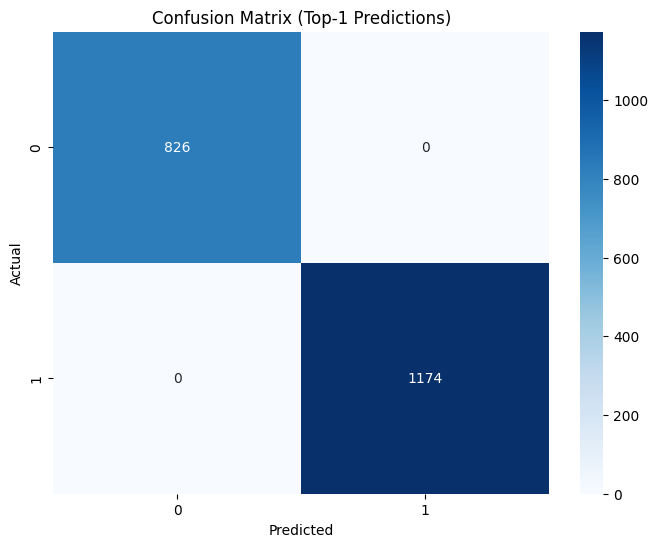

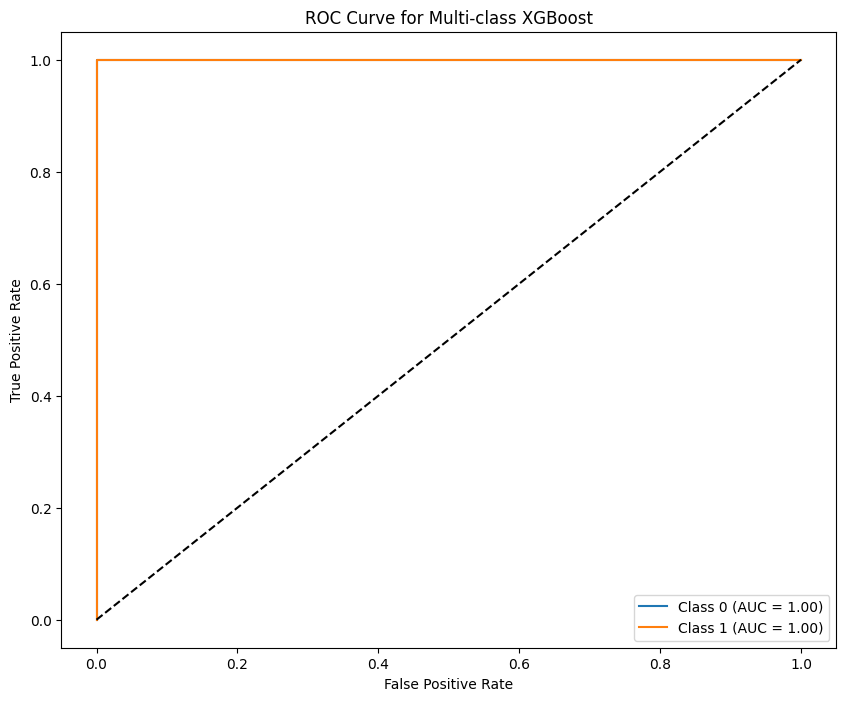

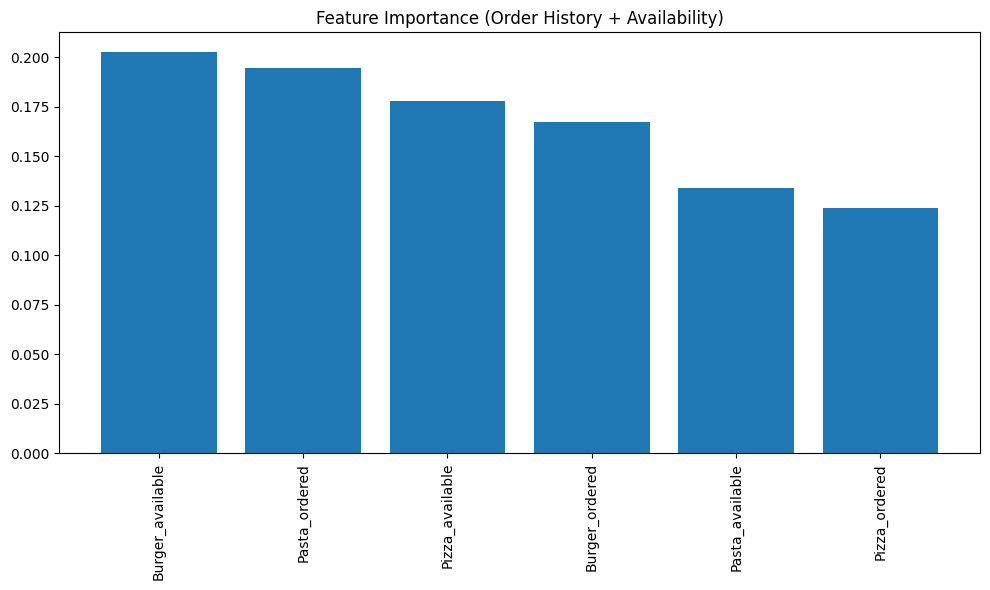

Accuracies saved to 'model_accuracies.csv'
Confusion Matrix saved to 'confusion_matrix.csv'
Feature Importances saved to 'feature_importances.csv'
Trained XGBoost model saved to 'xgboost_food_model.pkl'


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import accuracy_score, confusion_matrix, roc_curve, auc

import xgboost as xgb
import pickle  # added for saving model

# ---------------------------
# Step 1: Load CSV
# ---------------------------
df = pd.read_csv('food_orders.csv')  # replace with your CSV
print(df.head())

# ---------------------------
# Step 2: Identify Features and Target
# ---------------------------
ordered_cols = [col for col in df.columns if '_ordered' in col]
available_cols = [col for col in df.columns if '_available' in col]
features = ordered_cols + available_cols

X = df[features]
y = df['target']

# ---------------------------
# Step 3: Train-Test Split
# ---------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ---------------------------
# Step 4: Train XGBoost with Regularization
# ---------------------------
model = xgb.XGBClassifier(
    objective='multi:softprob',
    num_class=len(np.unique(y)),
    eval_metric='mlogloss',
    use_label_encoder=False,
    n_estimators=100,
    max_depth=3,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=1,
    reg_lambda=1,
    random_state=42
)

model.fit(X_train, y_train)

# ---------------------------
# Step 5: Predictions
# ---------------------------
y_prob = model.predict_proba(X_test)
y_pred = np.argmax(y_prob, axis=1)

# ---------------------------
# Step 6: Accuracy
# ---------------------------
top1_accuracy = accuracy_score(y_test, y_pred)

# ---------------------------
# Step 7: Top-3 Accuracy
# ---------------------------
top3_pred = np.argsort(y_prob, axis=1)[:, -3:]
top3_hits = [y_test.values[i] in top3_pred[i] for i in range(len(y_test))]
top3_accuracy = np.mean(top3_hits)

# ---------------------------
# Step 8: Confusion Matrix (for Top-1)
# ---------------------------
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=np.unique(y), yticklabels=np.unique(y))
plt.title("Confusion Matrix (Top-1 Predictions)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.savefig('confusion_matrix.png')
plt.show()

# ---------------------------
# Step 9: ROC Curve (Multi-class)
# ---------------------------
encoder = OneHotEncoder(sparse_output=False, categories=[np.unique(y)])
y_test_bin = encoder.fit_transform(y_test.values.reshape(-1, 1))

plt.figure(figsize=(10,8))
for i in range(len(np.unique(y))):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_prob[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'Class {i} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--')
plt.title("ROC Curve for Multi-class XGBoost")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.savefig('roc_curve.png')
plt.show()

# ---------------------------
# Step 10: Feature Importance
# ---------------------------
importances = model.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10,6))
plt.title("Feature Importance (Order History + Availability)")
plt.bar(range(len(features)), importances[indices], align='center')
plt.xticks(range(len(features)), [features[i] for i in indices], rotation=90)
plt.tight_layout()
plt.savefig('feature_importance.png')
plt.show()

# ---------------------------
# Step 11: Store and Output Results


# Store accuracies in a DataFrame and save to CSV
results_df = pd.DataFrame({
    'Metric': ['Top-1 Accuracy', 'Top-3 Accuracy'],
    'Value': [top1_accuracy, top3_accuracy]
})
results_df.to_csv('model_accuracies.csv', index=False)
print("Accuracies saved to 'model_accuracies.csv'")

# Save confusion matrix to CSV
cm_df = pd.DataFrame(cm, index=np.unique(y), columns=np.unique(y))
cm_df.index.name = 'Actual'
cm_df.columns.name = 'Predicted'
cm_df.to_csv('confusion_matrix.csv')
print("Confusion Matrix saved to 'confusion_matrix.csv'")

# Save feature importances to CSV
feature_importance_df = pd.DataFrame({
    'Feature': [features[i] for i in indices],
    'Importance': importances[indices]
})
feature_importance_df.to_csv('feature_importances.csv', index=False)
print("Feature Importances saved to 'feature_importances.csv'")

# ---------------------------
# Step 12: Save Trained Model as .pkl
# ---------------------------
model_filename = 'xgboost_food_model.pkl'
with open(model_filename, 'wb') as file:
    pickle.dump(model, file)

print(f"Trained XGBoost model saved to '{model_filename}'")